# 学生コホートの中退までの時間に関する生存時間分析


## エグゼクティブサマリー

**背景。** ある4年制大学の機関調査(IR)部門は、学生が離学するかどうかだけでなく、*いつ*離学するのかを理解したいと考えている。入学時のコホートを学期ごとに追跡すると、卒業する学生、中退する学生、そして観測期間が終了した時点でまだ在籍している学生が存在する。まだ在籍している学生の転帰は不明(右側打ち切り)であり、また卒業は学生を中退させることなくリスク集団から取り除くため、通常の合否回帰ではタイミング情報が捨てられ、打ち切りを無視した推定にはバイアスが生じる。適切な手法は**イベントまでの時間(生存時間)分析**であり、関心のあるイベントは**中退**、時間の尺度は在籍した学期数で測る。

**ビジネス上の問い。** 学生の**第1学期の学業成績状態**(早期警告フラグ)は、コホートの中退タイミングの軌跡を分離するのか。また調整後に中退ハザードを駆動する学生特性はどれか。これらの答えは早期警告システムに供給される。すなわち、推定された中退ハザードが高い学生には、介入が最も安価で効果的な最初の学期にアドバイジングによる働きかけを行うべきである。

**アプローチ。** 100人の学生コホートをインラインでシミュレーション(外部データなし)し、標準的な生存時間分析ワークフローを順に進める:

1. **PROC MEANS** で、観測された3つの転帰(卒業/中退/在籍中)にわたって予測変数をプロファイルし、シミュレートされたシグナルが妥当に振る舞うことを確認する。
2. **PROC FREQ** で、第1学期の学業成績状態と転帰をクロス集計し、カイ二乗の関連性検定を行う。
3. **PROC UNIVARIATE** で、成績状態別に中退までの時間のロバストなパーセンタイルを報告する。
4. **PROC LIFETEST** で、成績状態別に層別化したカプラン・マイヤー中退曲線を推定し、**ログランク**検定と**ウィルコクソン**検定による同等性の検定を行う。
5. **PROC PHREG** で、中退ハザードに対する多変量**Cox比例ハザード**モデルを、参照コード化した `CLASS` 効果、Efronのタイ処理、リスク限界の信頼区間とともに当てはめる。

**データが示すもの。** シミュレートされた100人の学生のうち、12学期の打ち切り時点で**49人が中退、49人が卒業、2人が在籍中のまま**であった。第1学期に**学業警告**フラグが立った学生(第1学期GPAが2.5未満)は、良好な成績状態の学生よりもはるかに速く中退する:中退までの時間の中央値は**3.8学期対8.7学期**であり、この分離はログランク検定で確認される(カイ二乗 = 10.73、*p* = 0.0011)。Coxモデルは、第1学期GPA(GPA1ポイントあたりハザード比0.21、*p* < 0.0001)、高校GPA(HR 0.45、*p* = 0.027)、第一世代の地位(HR 2.03、*p* = 0.031)を中退の有意な調整済み駆動要因として特定する一方、Pell給付金の地位はGPAを制御すると有意ではない(HR 0.95、*p* = 0.85)。

> *すべての数値は説明のためのものであり、合成データから生成されたもので、実際の学生記録ではない。この環境はライセンスなしで実行されるため、コホートは100人の学生規模とした。*


## データソース

すべてのデータは**合成**であり、最初のDATAステップで `CALL STREAMINIT(20260611)` と `RAND` 関数を用いてインラインで生成される。外部ファイルやネットワークアクセスはない。1行がシミュレートされた1人の学生に対応する。

**データセット `enrollments`**(100行、学生1人につき1行)

| 変数 | 型 | 説明 | 生成分布 |
|----------|------|-------------|--------------------------|
| `student_id` | Num | 学生の一意キー | 連番 1–100 |
| `first_gen` / `first_gen_lbl` | Num / Char | 第一世代フラグ(0/1)とラベル | ベルヌーイ、約42% |
| `pell` | Num | Pell給付金(経済的必要度)フラグ(0/1) | ベルヌーイ、約42% |
| `program` | Char | STEM / BUS / HUM | カテゴリカル(約42% / 32% / 26%) |
| `hs_gpa` | Num | 高校GPA(1.8–4.0) | 正規分布(3.00, 0.42)、クランプ |
| `term1_gpa` | Num | 第1学期の大学GPA(0–4.0) | f(hs_gpa, program) + 正規ノイズ |
| `standing` | Char | 第1学期の学業成績状態 | `term1_gpa < 2.5` → 学業警告、それ以外は良好な成績状態 |
| `time_terms` | Num | イベントまたは打ち切りまでの在籍学期数 | 競合ワイブル抽出;12で打ち切り |
| `dropped` | Num | 中退イベント指標(1 = 中退、0 = 打ち切り) | 導出 |
| `outcome` | Char | 卒業 / 中退 / 在籍中 | 競合抽出から導出 |

対数スケール上の潜在線形予測子が、各学生の**中退率**を第1学期GPA、高校GPA、第一世代の地位、経済的必要度に結びつけており、予測変数は真の(しかしノイズを含む)シグナルを持つ。中退と卒業は**競合する**潜在時間(ワイブル)として抽出され、12学期のウィンドウ内で先に発生した方が観測される転帰となり、いずれも起こらずに第12学期に到達した学生は右側打ち切りとなる。生存時間モデルでは**イベントは中退**(`dropped = 1`)であり、卒業と在籍継続はいずれも打ち切り(`dropped = 0`)として扱う。


## 1. 学生コホートのシミュレーション

最初のセルでは100人の学生からなる合成コホートを構築する。対数スケール上の潜在線形予測子が、各学生の中退率を第1学期GPA、高校GPA、第一世代の地位、Pellの地位に結びつける。中退と卒業は**競合する**潜在時間(ワイブル抽出)として生成され、12学期の観測ウィンドウ内で先に起こった方が観測される転帰となり、中退も卒業もせずに第12学期に到達した学生は右側打ち切りとなる。第1学期GPAが2.5未満の学生には**学業警告**フラグが立つ — これが生存時間ステップで検定する早期警告シグナルである。乱数抽出には再現性のために `CALL STREAMINIT` を用い、一様分布・正規分布・ワイブル分布にわたって `RAND` 関数を使用する。ハードな下限とクランプによって、すべての値が妥当な範囲(GPAは0–4.0)に保たれる。


In [1]:
データ enrollments;
    呼出 streaminit(20260611);
    長さ standing $30 first_gen_lbl $16 program $4 outcome $16;
    見出 student_id     = "学生ID"
          hs_gpa         = "高校GPA"
          term1_gpa      = "第1学期GPA"
          time_terms     = "在籍学期数"
          standing       = "第1学期の学業成績状態"
          first_gen_lbl  = "第一世代区分"
          outcome        = "観測された転帰"
          dropped        = "中退イベント指標"
          pell           = "Pell給付フラグ"
          first_gen      = "第一世代フラグ"
          program        = "専攻課程";
    繰返 student_id = 1 から 100;
        /* 第一世代フラグと経済的必要度フラグ */
        first_gen = (rand("uniform") < 0.42);
        もし first_gen なら first_gen_lbl = "第一世代";
        他                  first_gen_lbl = "継続世代";
        pell = (rand("uniform") < 0.42);

        /* 専攻課程 */
        v = rand("uniform");
        もし      v < 0.42 なら program = "STEM";
        他 もし v < 0.74 なら program = "BUS";
        他                  program = "HUM";

        /* 学業準備度と第1学期成績 */
        hs_gpa = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        term1_gpa = round(MIN(4.0, MAX(0.0,
                     0.55*hs_gpa + 1.05 + 0.12*(program="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* 早期警告フラグ：第1学期GPAが2.5未満 = 学業警告 */
        もし term1_gpa < 2.5 なら standing = "学業警告";
        他                    standing = "良好な成績状態";

        /* 対数スケール上の潜在中退ハザード：低いGPA、第一世代、
           Pellの地位が中退率を高める。 */
        eta = -1.05
             - 1.45*(term1_gpa - 2.8)
             - 0.55*(hs_gpa - 3.0)
             + 1.05*first_gen
             + 0.45*pell;
        drop_rate = EXP(eta);

        /* 競合する潜在時間（学期）：中退 対 卒業 */
        t_drop = rand("weibull", 1.2, 7.0) / MAX(0.30, drop_rate);
        t_grad = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(term1_gpa - 2.8));

        /* 12学期の管理的打ち切りウィンドウ */
        censor_at = 12;
        もし t_drop <= t_grad かつ t_drop <= censor_at なら 繰返;
            outcome = "中退";   dropped = 1; time_terms = t_drop;
        終了;
        他 もし t_grad < t_drop かつ t_grad <= censor_at なら 繰返;
            outcome = "卒業"; dropped = 0; time_terms = t_grad;
        終了;
        他 繰返;
            outcome = "在籍中";  dropped = 0; time_terms = censor_at;
        終了;
        time_terms = round(time_terms, 0.1);
        出力;
    終了;
    保持 student_id first_gen first_gen_lbl pell program hs_gpa
         term1_gpa standing time_terms dropped outcome;
実行;


NOTE: DATA enrollments


NOTE: Wrote enrollments (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. 観測された転帰別の予測変数のプロファイル

モデリングの前に、シミュレートされた予測変数が期待される方向に動くことを確認する。**PROC MEANS** は、観測された3つの転帰それぞれの中での各数値予測変数について、件数、平均、ばらつき、範囲を報告する。

コホートは**卒業49人 / 中退49人 / 在籍中2人**に分かれる。卒業者は中退した学生より高い第1学期GPA(平均 **2.94** 対 **2.54**)と高い高校GPA(**3.10** 対 **2.90**)を持つ — まさに分析が期待する学業準備度の勾配である。在籍中の2人の学生は `time_terms` で12学期の打ち切り上限にちょうど位置しており(平均12.00、標準偏差0)、これは減耗分析が尊重しなければならない右側打ち切りである。中退した学生の中では、イベントは早期に到来する:平均 **3.31学期**、0.1から8.9の範囲。


In [2]:
処理 平均 データ=enrollments n mean std MIN MAX maxdec=2;
    分類 outcome;
    変数 hs_gpa term1_gpa time_terms;
実行;

                                                  The MEANS Procedure

                                          Analysis Variable : hs_gpa 高校GPA

        観測された転帰                        N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------------
        中退                                49           2.90           0.45           2.01           3.89
        卒業                                49           3.10           0.46           1.97           4.00
        在籍中                                2           3.10           0.17           2.98           3.22
        ------------------------------------------------------------------------------------------------

                                      Analysis Variable : term1_gpa 第1学期GPA

        観測された転帰                        N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. 早期警告フラグは転帰を追跡するか?

早期警告システムは、第1学期GPAが2.5を下回る学生に**学業警告**フラグを立てる。**PROC FREQ** はそのフラグを観測された転帰とクロス集計し、カイ二乗の関連性検定を行う。行・列・全体のパーセンテージを抑制(`NOROW NOCOL NOPERCENT`)して生の件数を表示し、コホート構成のために `standing` と第一世代の地位の一元度数を追加する。

クロス集計は明白である:**学業警告**フラグが立った **29** 人の学生のうち、**21人が中退**し、卒業したのはわずか8人だった;良好な成績状態の **71** 人のうち、**41人が卒業**し、28人が中退した。関連は有意である(カイ二乗 = 9.21、df = 2、*p* = 0.0100;クラメールのV = 0.30)。ただし**一緒に印字される警告**に注意:100人の学生と卒業2人の薄い「在籍中」列があるため、表のセルの3分の1で期待度数が5未満となり、ここでのカイ二乗*p*値は脆弱である。その脆弱さこそが、3×2の表ではなく完全なタイミング情報を用いる次節の生存時間検定が、成績状態効果のより信頼できる検定である理由である。


                                                   The FREQ Procedure

Table of 第1学期の学業成績状態 by 観測された転帰

第1学期の学業成績状態                     |        中退 |        卒業 |       在籍中 |      Total
--------------------------------+-----------+-----------+-----------+-----------
学業警告                            |        21 |         8 |         0 |         29
--------------------------------+-----------+-----------+-----------+-----------
良好な成績状態                         |        28 |        41 |         2 |         71
--------------------------------+-----------+-----------+-----------+-----------
Total                           |        49 |        49 |         2 |        100

Statistics for Table of 第1学期の学業成績状態 by 観測された転帰

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V              


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_standing_outcome.spec.json
NOTE: ODS plot written: freq_standing.spec.json
NOTE: ODS plot written: freq_first_gen_lbl.spec.json
NOTE: PROC FREQ statement used.


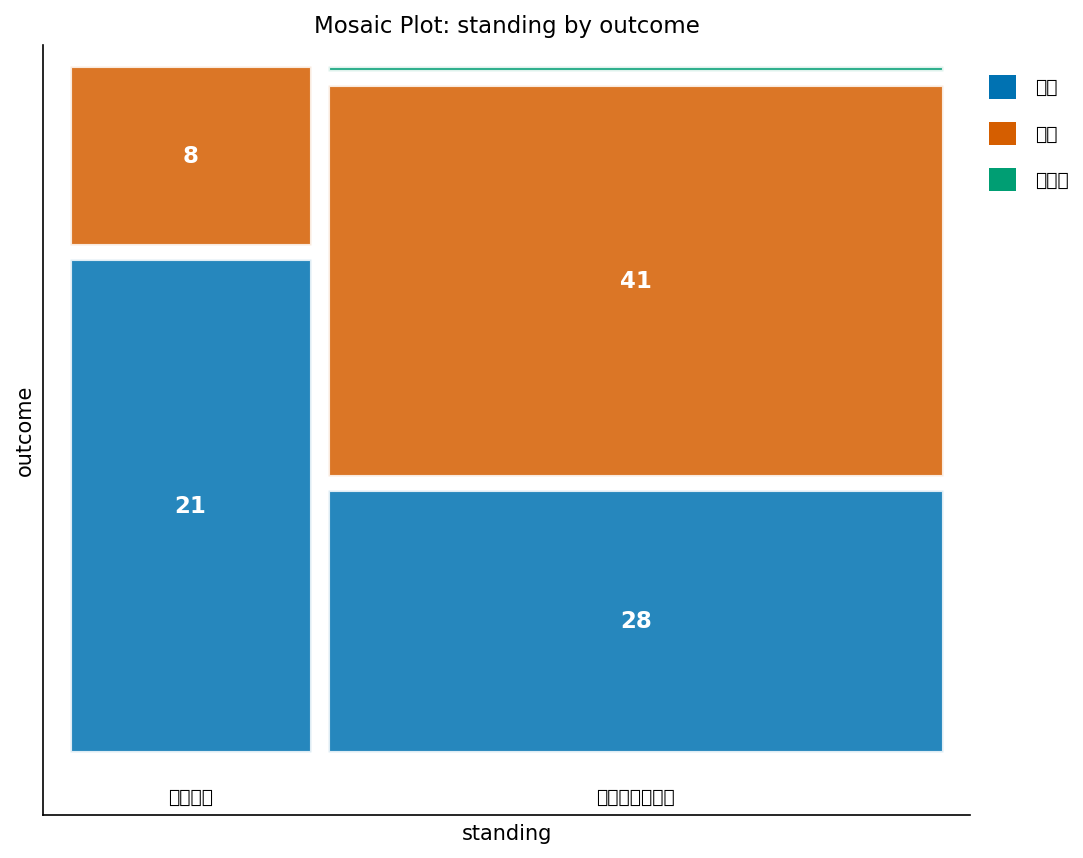

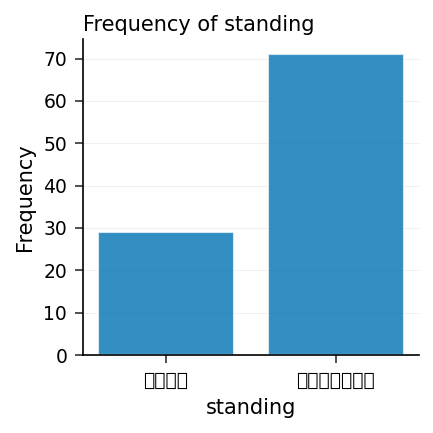

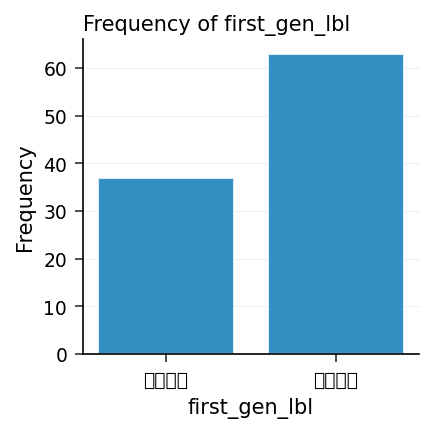

In [3]:
処理 度数 データ=enrollments;
    TABLES standing*outcome / chisq norow nocol nopercent;
    TABLES standing first_gen_lbl;
実行;

## 4. 中退はいつ起こるか? 成績状態別のパーセンタイル

実際に中退した学生について、*いつ*離学したのか? **PROC UNIVARIATE**(`dropped = 1` に限定)は、各成績状態グループ内での中退までの時間の第10、第50(中央値)、第90パーセンタイルを報告し、出力データセットに書き出してから印字する。これは分布を仮定せずに中退タイミングのばらつきを記述する。

離学した学生の中での中退の中央値は、**学業警告**でおよそ **2.4** 学期、良好な成績状態で **2.6** 学期の前後で発生する — *中退を条件とすれば*、どちらのグループも早期に離学する傾向があるため、両者は近い。したがって成績状態効果は主として中退が*いつ*起こるかではなく、*何人*の学生が中退し、リスク集団がどれだけ速く薄くなるかに関するものである。これはまさに次節のカプラン・マイヤー曲線が捉えるものである。


In [4]:
処理 単変量 データ=enrollments NOPRINT;
    条件 dropped = 1;
    分類 standing;
    変数 time_terms;
    出力 out=drop_ref pctlpts=10 50 90 pctlpre=t_ p=;
実行;

処理 印刷 データ=drop_ref noobs 見出;
    見出 standing = "学業成績状態"
          t_10 = "第10パーセンタイル（学期）"
          t_50 = "中央値（学期）"
          t_90 = "第90パーセンタイル（学期）";
    表題 "学業成績状態別 中退までの時間パーセンタイル（学期）";
実行;
表題;

                                               学業成績状態別 中退までの時間パーセンタイル（学期）                                               

               学業成績状態                          第10パーセンタイル（学期）                中央値（学期）                          第90パーセンタイル（学期）
学業警告                                                      0.2                    2.4                                     7.9
良好な成績状態                                                   0.4                    2.6                                     8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset drop_ref has 2 observations and 4 variables.
NOTE: PROC PRINT data=drop_ref

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. 学業成績状態別のカプラン・マイヤー中退曲線

いよいよ生存時間分析の核心ステップである。**PROC LIFETEST** は、*中退までの時間*に対するノンパラメトリックな**カプラン・マイヤー**生存関数を推定し、卒業と在籍継続を打ち切りとして扱う(`dropped(0)` が打ち切り観測を示す)。`standing` で層別化するとグループごとに1本の中退曲線が得られ、`TEST=(LOGRANK WILCOXON)` はそれらの曲線が異なるかどうかを2つの相補的な検定で調べる:**ログランク**検定はすべてのイベント時点を等しく重み付けする(遅い差に敏感)一方、**ウィルコクソン**検定は早いイベント時点を強く重み付けする(早期の減耗に敏感)。`PLOTS=SURVIVAL` は重ね描きした生存曲線グラフィックを要求する。

コホート全体では**49件の中退イベントと51件の打ち切り**観測がある。曲線は明確に分離する:学業警告の学生は**生存(中退までの時間)の中央値3.8学期**に達する一方、良好な成績状態の学生はその2倍以上長く持ちこたえる(**8.7学期**)。両検定とも同等性を棄却する — **ログランク カイ二乗 = 10.73、*p* = 0.0011;ウィルコクソン カイ二乗 = 7.66、*p* = 0.0056** — そして比較可能な統計量から、この差は早期のスパイクだけでなく在籍ウィンドウ全体にわたって持続していることがわかる。プロットはメッセージを一目瞭然にする:オレンジの学業警告曲線は最初の4学期を通じて急激に低下する一方、青の良好な成績状態曲線は高いまま留まる。


    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: 第1学期の学業成績状態 = 学業警告

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.0804              22       


NOTE: PROC LIFETEST data=enrollments

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


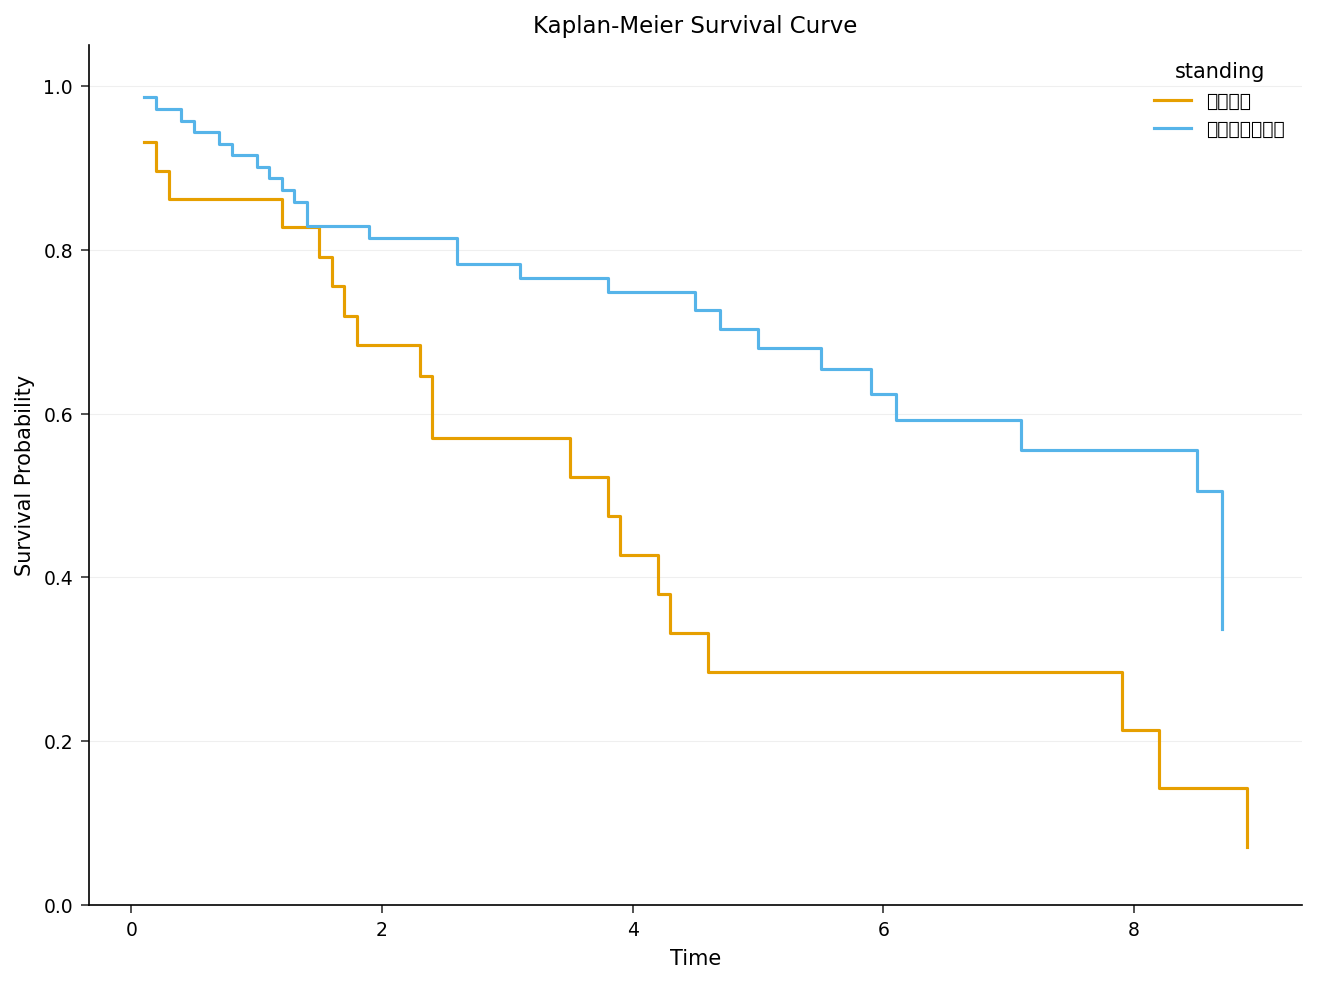

In [5]:
処理 LIFETEST データ=enrollments PLOTS=SURVIVAL METHOD=km;
    TIME time_terms*dropped(0);
    層 standing / TEST=(logrank WILCOXON);
実行;

## 6. 中退に対する多変量Cox比例ハザードモデル

**PROC PHREG** は、中退ハザードに対する**Cox比例ハザード**モデルを当てはめ、予測変数を同時に調整する。主な要求項目:

- `dropped(0)` は**中退**をイベントとし、それ以外をすべて打ち切りとする。
- `CLASS first_gen_lbl (ref="継続世代") / param=ref` は第一世代因子を参照コード化し、そのハザード比が継続世代の学生を基準に読まれるようにする。
- `TIES=EFRON` は複数の学生が同じ学期に離学する場合に推奨されるタイ処理の近似である。
- `RL` はハザード比(リスク限界)の信頼区間を追加する。
- `HAZARDRATIO` ステートメントは、参照グループに対する第一世代のコントラストを報告する。

ハザード比が1より大きいことは*より速い*中退(高リスク)を意味し、1未満は*より遅い*中退(保護的)を意味する。


In [6]:
処理 PHREG データ=enrollments;
    分類 first_gen_lbl (REF="継続世代") / PARAM=REF;
    模型 time_terms*dropped(0) = hs_gpa term1_gpa first_gen_lbl pell
          / TIES=efron rl;
    hazardratio "第一世代 対 継続世代" first_gen_lbl / DIFF=REF;
実行;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                            Analysis of Maximum Likelihood Estimates                                            

Parameter                         DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
--------------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
HS_GPA        


NOTE: PROC PHREG data=enrollments

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. 解釈と次のステップ

**出力を端から端まで読む:**

- **PROC MEANS** はシミュレートされたシグナルを裏付ける:卒業した学生は中退した学生より高い第1学期GPA(2.94対2.54)と高校GPA(3.10対2.90)を持ち、在籍中の学生は12学期の上限に位置する — 生存時間モデルが尊重する右側打ち切りである。
- **PROC FREQ** は、第1学期の学業警告フラグが転帰を追跡することを示す(フラグの立った29人中21人が中退;良好な成績状態の71人中41人が卒業;*p* = 0.0100)一方で、セルの疎な100人の表ではカイ二乗が脆弱であることを正直に示している。
- **PROC UNIVARIATE** は、*中退を条件とすれば*両グループとも早期に離学すること(中央値およそ2.4–2.6学期)を示す;成績状態効果は、離学する者の中でのタイミングではなく、何人の学生が中退しリスク集団がどれだけ速く薄くなるかに関するものである。
- **PROC LIFETEST** は見出しをもたらす:成績状態によって鋭く分離するカプラン・マイヤー中退曲線(中央値3.8対8.7学期;ログランク *p* = 0.0011、ウィルコクソン *p* = 0.0056)。早期警告フラグは、中退タイミングの真の、統計的に裏付けられた識別因子である。
- **PROC PHREG** は各予測変数の中退ハザードに対する調整済み効果を定量化する。調整後、**第1学期GPAが最も強い保護因子**である(GPA1ポイントあたりハザード比0.21、95% CI 0.10–0.44、*p* < 0.0001):GPAが1ポイント増えるごとに中退ハザードはおよそ5分の4だけ減少する。**高校GPA**も保護的である(HR 0.45、95% CI 0.22–0.91、*p* = 0.027)。**第一世代の学生**は、同じGPAを持つ継続世代の同輩の約2倍の中退ハザードに直面する(HR 2.03、95% CI 1.07–3.84、*p* = 0.031)。**Pellの地位はGPAを制御すると有意ではない**(HR 0.95、95% CI 0.53–1.69、*p* = 0.85)— 生のリスク因子が調整後に消えうるという有用な注意喚起である。大域帰無仮説は決定的に棄却される(尤度比 カイ二乗 = 31.11、自由度4、*p* < 0.0001)。

**機関がこれをどう活用するか。** Coxモデルは学生ごとの線形予測子(リスクスコア)を生成し、中退ハザードによってコホートを順位付けする;最も高リスクの学生 — 低い第1学期GPAと第一世代の地位の組み合わせ — は、介入が最も安価で効果的な最初の学期に早期警告アドバイジングへ振り向けられる。カプラン・マイヤー比較は、アドバイザーが第1学期末に既に収集している単一の擁護可能な基準、すなわち学業成績状態を提供する。

**注意点と拡張。** (1) この合成コホートは中退モデルにおいて卒業を打ち切りとして扱う;実データでは卒業と中退は真の**競合リスク**であり、PROC PHREG の `EVENTCODE=` を用いた競合リスク(累積発生率)拡張は中退確率の過大評価を避けられる。(2) 比例ハザード仮定は、すべての学期にわたる単一のハザード比を信頼する前に確認すべきである(PHREG の `ASSESS PH` またはショーンフェルト残差)。(3) 時間依存共変量 — 学期ごとのGPA、財政援助の変化、履修負荷 — は在籍データでは一般的であり、PHREG のプログラミングステートメントで自然に扱える。(4) ここでの100人の学生コホートはライセンスなし実行の上限に合わせたものである;本番の分析では数千人の学生を扱い、あらゆる信頼区間を狭めることになる。運用上行動を起こす前に、配備したリスクスコアを常にホールドアウトのコホートで検証すること。
